

Como analista de datos, el objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco =pd.read_csv('/datasets/oecd_city_economy.csv') 

In [3]:

print(traffic.head())# mostrar las primeras 5 filas de traffic

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [4]:

print(eco.head())# mostrar las primeras 5 filas de eco

   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   
3  2023        brasilia     Brazil       15.999,00           8.3%   
4  2023        salvador     Brazil        8.761,00          13.1%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  
3         13,50           4,70  
4         16,00           3,90  


**Tip:** Si no usas `print()` la tabla se vera mejor.





Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.




In [5]:
traffic.info()# Examinar la estructura de traffic
print(traffic.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [6]:
eco.info()# Examinar la estructura de eco
print(eco.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB
   Year            City    Country City GDP/capita Unemployment %  \
0  2023    buenos-aires  Argentina       15.782,00           6.2%   
1  2023       sao-paulo     Brazil       14.475,00           9.1%   
2  2023  rio-de-janeiro     Brazil       13.142,00           9.8%   

  PM2.5 (μg/m³) Population (M)  
0          15,2          15,30  
1         29,50          22,50  
2         19,10          13,60  



Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.




In [ ]:
# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={
    'Country': 'country',
    'UpdateTimeUTC': 'update_time_utc',
    'UpdateTimeUTCWeekAgo' : 'update_time_utc_week_ago',
    'JamsDelay': 'jams_delay',
 'TrafficIndexLive' :'traffic_index_live' ,
    'JamsLengthInKms':'jams_length_in_kms',
    'JamsCount':'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
     'TravelTimeHistoricPer10KmsMins' :  'travel_time_historic_per_10Kms_mins',
    'MinsDelay' : 'mins_delay' ,
    'year' : 'year',
    'City' : 'city'
    })

# verificar cambios
(traffic.columns)

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10Kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'Population (M)' : 'population_m',
    'Year':'year',
    'City' : 'city',
    'PM2.5 (μg/m³)': 'pm25'
    
    

})

# verificar cambios
(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

In [9]:
# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'Population (M)' : 'population_m',
    'Year':'year',
    'City' : 'city',
    'PM2.5 (μg/m³)': 'pm25'
})

# verificar cambios
(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')





Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.




In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] =pd.to_datetime(traffic['update_time_utc'], errors='coerce') 
traffic['update_time_utc_week_ago'] =pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce') 

# verificar el cambio
(traffic.info)

<bound method DataFrame.info of         country       city         update_time_utc  jams_delay  \
0           ARE  abu-dhabi 2025-01-13 04:01:30.001       650.7   
1           ARE  abu-dhabi 2025-01-13 03:46:00.000       540.4   
2           ARE  abu-dhabi 2025-01-13 02:46:30.000        71.8   
3           ARE  abu-dhabi 2025-01-13 01:46:30.001         8.2   
4           ARE  abu-dhabi 2025-01-13 00:01:30.000         1.1   
...         ...        ...                     ...         ...   
1004459     ZAF   pretoria 2024-10-01 12:31:30.000       195.1   
1004460     ZAF   pretoria 2024-10-01 11:31:30.000        78.3   
1004461     ZAF   pretoria 2024-10-01 10:01:30.000        85.0   
1004462     ZAF   pretoria 2024-10-01 09:01:30.000        68.1   
1004463     ZAF   pretoria 2024-10-01 08:46:30.000        67.7   

         traffic_index_live  jams_length_in_kms  jams_count  \
0                      36.0               109.1       162.0   
1                      30.0               101.4  

In [11]:
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)

eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)

eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Calcula la población total en unidades absolutas
eco['population'] = eco['population_m'] * 1_000_000

# Verificar los cambios
print(traffic.dtypes)
print(eco.info())
print(eco.head(3))

country                                        object
city                                           object
update_time_utc                        datetime64[ns]
jams_delay                                    float64
traffic_index_live                            float64
jams_length_in_kms                            float64
jams_count                                    float64
traffic_index_week_ago                        float64
update_time_utc_week_ago               datetime64[ns]
travel_time_live_per_10kms_mins               float64
travel_time_historic_per_10Kms_mins           float64
mins_delay                                    float64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 

In [12]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


In [13]:
eco['city_gdp_capita'].head()

0    15782.0
1    14475.0
2    13142.0
3    15999.0
4     8761.0
Name: city_gdp_capita, dtype: float64





Identificar el año de cada registro y mantener solo los registros del 2024.



In [14]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic['update_time_utc'].dt.year# traffic['year'] = ...

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10Kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [15]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco.copy()
# traffic_2024 = traffic[...].copy()
# eco_2024 = ...

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10Kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0
3,2023,brasilia,Brazil,15999.0,8.3,"13,50",4.7,4700000.0
4,2023,salvador,Brazil,8761.0,13.1,"16,00",3.9,3900000.0




Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.




<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =(
    traffic_2024
    .groupby(['city', 'country', 'year'], as_index=False)
    .agg(
        jams_delay=('jams_delay', 'mean'),
        traffic_index_live=('traffic_index_live', 'mean'),
        jams_length_kms=('jams_length_in_kms', 'mean'),
        jams_count=('jams_count', 'mean'),
        mins_delay=('mins_delay', 'mean'),
        travel_time_live_per_10kms_mins=('travel_time_live_per_10kms_mins', 'mean'),
        travel_time_hist_per_10kms_mins=('travel_time_historic_per_10Kms_mins', 'mean')
    )
)     

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [17]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)# tu código aquí

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_hist_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694




Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.




<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_hist_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()# traffic_2024_small = traffic_city_year_2024[ ... ].copy()
eco_2024_small = eco_2024[right_cols].copy()# eco_2024_small = ...

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')
 

# Mostrar las primeras 5 filas
print(merged.head())

             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_kms  jams_count  mins_delay  travel_time_live_per_10kms_mins  \
0        44.038129   68.805422    0.487228                        18.304538   
1       140.893564  230.566550    1.699628                        24.992185   
2        18.337133   27.280140    0.193442                        13.338658   
3       100.287844  137.359860    0.416566                        17.907916   
4        30.050044   46.898164    0.139965                        17.258700   

   travel_time_hist_per_10kms_mins  city_gdp_capita  unemployment_pct   pm25  \
0                        17.817311  


Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

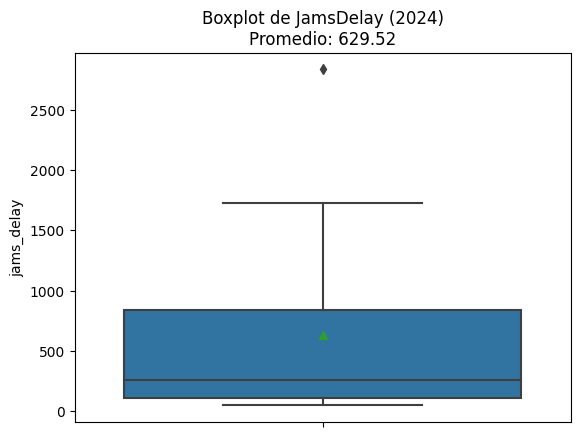

In [ ]:


# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
sns.boxplot(data=merged, y='jams_delay', showmeans=True)


# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')


plt.show()




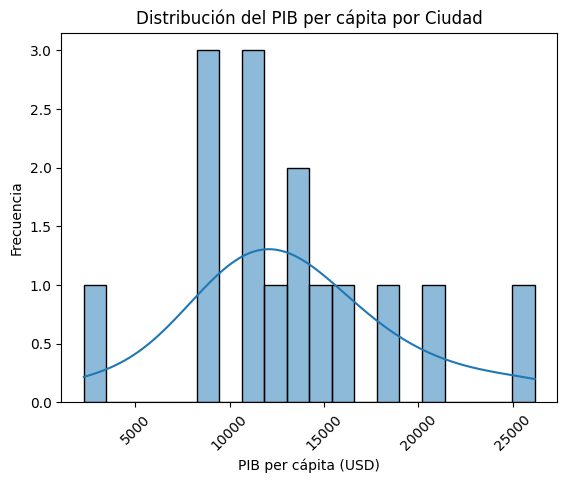

In [20]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita', bins=20, kde=True)
plt.xticks(rotation=45)
plt.title('Distribución del PIB per cápita por Ciudad')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia')

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Recomiendo utilizar una cantidad menor de `bins` ya que en un histograma lo mejor es no dejar espacios entre cada una de las barras
</div>


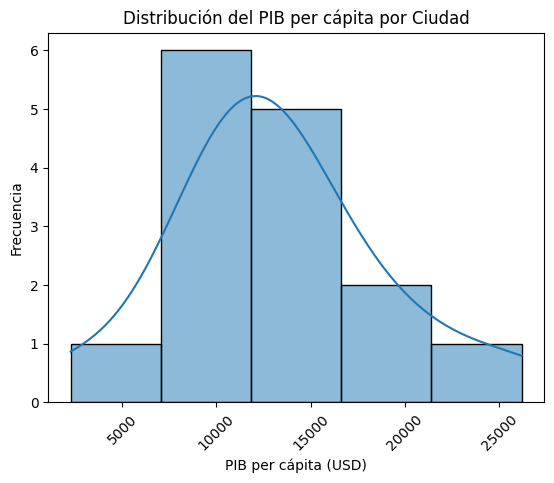

In [21]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
sns.histplot(data=merged, x='city_gdp_capita', bins=5, kde=True)
plt.xticks(rotation=45)
plt.title('Distribución del PIB per cápita por Ciudad')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia')

plt.show()

In [29]:
merged['city_gdp_capita']

0     11124.0
1     11442.0
2     16251.0
3     18117.0
4     12381.0
5      8512.0
6     13472.0
7     21111.0
8     26176.0
9     11801.0
10     9189.0
11    13349.0
12     8899.0
13     2277.0
14    14703.0
Name: city_gdp_capita, dtype: float64

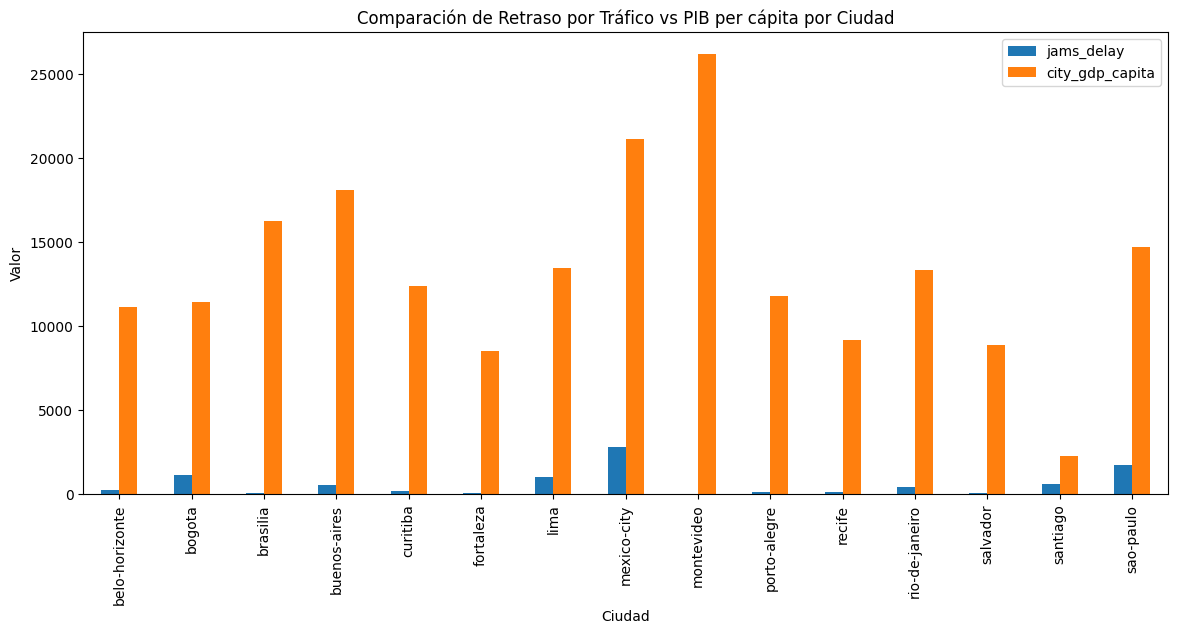

In [30]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
#merged.plot( ... , y=['jams_delay', 'city_gdp_capita'])
merged.plot(x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar', figsize=(14, 6))
plt.title('Comparación de Retraso por Tráfico vs PIB per cápita por Ciudad')
plt.xlabel('Ciudad')
plt.ylabel('Valor')
plt.xticks(rotation=90)
plt.show()

In [31]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)